In [45]:
import pandas as pd 
import os
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error
from math import sqrt
import math
import gpytorch
from matplotlib import pyplot as plt
from torch.nn.functional import mse_loss
from sklearn.metrics import mean_absolute_error
import torch.nn as nn


In [46]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
mm = pd.read_excel('/Users/taliacho/Downloads/Ranger/Bryan-Ranger/body_comp/US_data_1.29.24.xlsx')
mm['BM'] = mm[['B1M', 'B2M', 'B3M']].mean(axis=1,skipna=True)
mm['BA'] = mm[['B1A', 'B2A', 'B3A']].mean(axis=1,skipna=True)
mm['AA'] = mm[['A1A', 'A2A', 'A3A']].mean(axis=1,skipna=True)
mm['AM'] = mm[['A1M', 'A2M', 'A3M']].mean(axis=1,skipna=True)
mm['QA'] = mm[['Q1A', 'Q2A', 'Q3A']].mean(axis=1,skipna=True)
mm['QM'] = mm[['Q1M', 'Q2M', 'Q3M']].mean(axis=1,skipna=True)

mm_avg = mm[['Study ID','BM','BA','AM','AA','QM','QA']]

In [48]:
hp = pd.read_excel('/Users/taliacho/Downloads/Ranger/Bryan-Ranger/body_comp/Data_11.5.23.xlsx')
hp_check = hp[['Study_ID','PerFM','PerFFM']]
hp_avg = hp[['PerFM','PerFFM']]

    Study ID        BM        BA        AM        AA        QM        QA  \
0    1111517  0.970000  0.233333  0.243333  0.220000  1.073333  0.216667   
1    2111617  0.980000  0.166667  0.320000  0.253333  1.140000  0.183333   
2    3120117  0.790000  0.140000  0.170000  0.126667  0.970000  0.146667   
3    4120117  0.753333  0.176667  0.160000  0.176667  1.106667  0.180000   
4    5120817  0.526667  0.113333  0.153333  0.100000       NaN       NaN   
..       ...       ...       ...       ...       ...       ...       ...   
60  61051619  0.903333  0.260000  0.283333  0.256667  1.120000  0.266667   
61  63053119  0.983333  0.196667  0.210000  0.293333  1.193333  0.330000   
62  65050619  0.950000  0.216667  0.326667  0.330000  0.793333  0.566667   
63  66061919  0.873333  0.203333  0.256667  0.323333  1.416667  0.376667   
64  67062119  0.703333  0.253333  0.250000  0.340000  1.266667  0.333333   

    PerFM  PerFFM  
0     6.7    93.3  
1     7.7    92.3  
2     5.0    95.0  
3     8

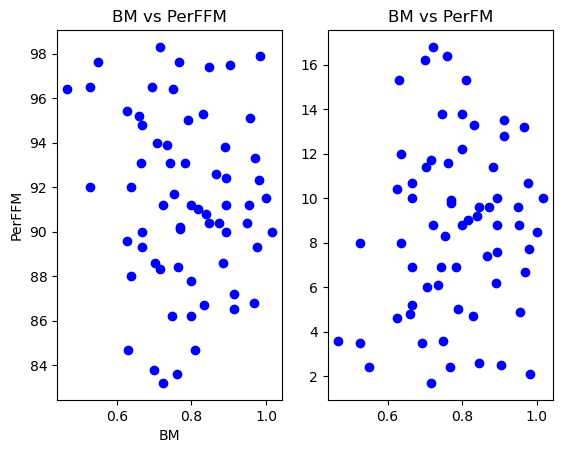

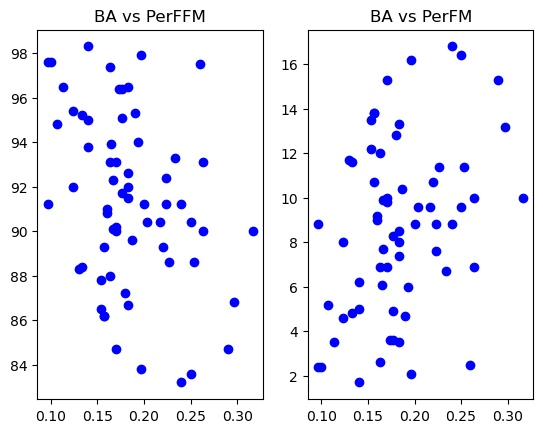

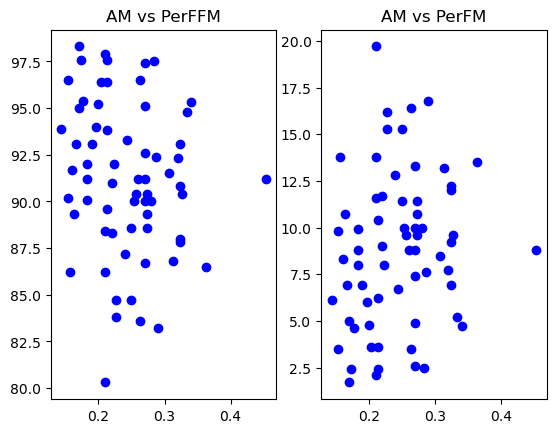

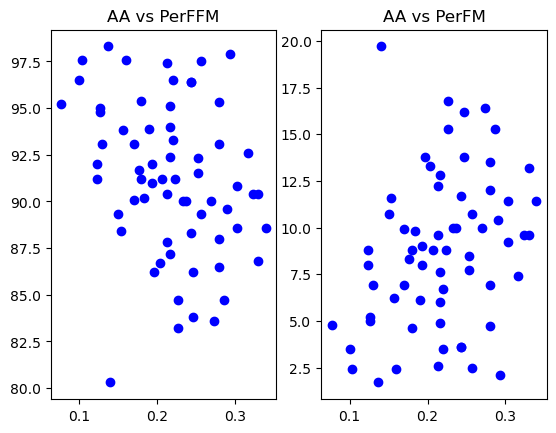

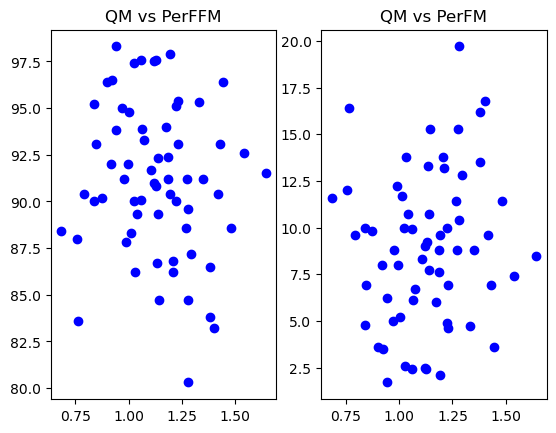

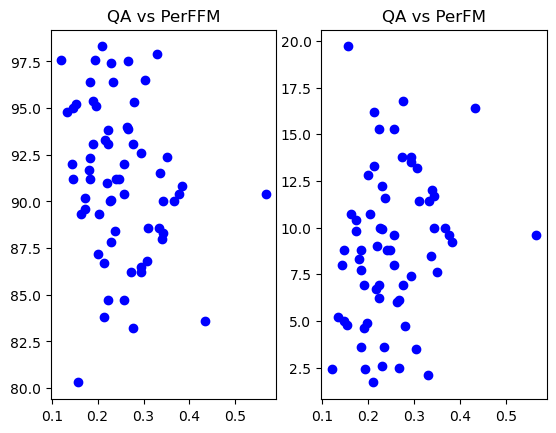

In [49]:
df = pd.concat([mm_avg, hp_avg], axis=1)
print(df)
plt.subplot(1, 2, 1)
plt.plot(df['BM'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('BM vs PerFFM')
plt.xlabel('BM')
plt.ylabel('PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['BM'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('BM vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['BA'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('BA vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['BA'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('BA vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['AM'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('AM vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['AM'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('AM vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['AA'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('AA vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['AA'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('AA vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['QM'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('QM vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['QM'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('QM vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['QA'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('QA vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['QA'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('QA vs PerFM')
plt.show()

In [50]:
matrix_3d_df = np.zeros((len(df), 2, 12))
for matrix_index in range(12):  
    idx = 1 + matrix_index // 2  
    matrix_3d_df[:, 0, matrix_index] = df.iloc[:, idx].values
    if matrix_index % 2 == 0:
        matrix_3d_df[:, 1, matrix_index] = df.iloc[:, 7].values
    else:
        matrix_3d_df[:, 1, matrix_index] = df.iloc[:, 8].values

In [51]:
def split_data(data,train_size=0.8,test_size=0.1,random_state=None): #diff  outcomes for each run
    train,temp=train_test_split(data,train_size=train_size,random_state=random_state)
    test_and_valid_size = 1.0-train_size
    test_ratio = test_size/test_and_valid_size
    test,valid = train_test_split(temp,test_size=test_ratio,random_state=random_state)
    return train, test, valid

In [52]:
rmse = torch.zeros(12, 1)
mse = torch.zeros(12, 1)
mae = torch.zeros(12, 1)

# Define the loss functions
mse_loss = nn.MSELoss()
mae_loss = nn.L1Loss()

for index in range(12):
    train, test, valid = split_data(torch.tensor(matrix_3d_df[:, :, index], dtype=torch.float32))
    train = train[~torch.isnan(train).any(dim=1)]
    test = test[~torch.isnan(test).any(dim=1)]
    valid = valid[~torch.isnan(valid).any(dim=1)]

    train_x = train[:, 0]
    train_y = train[:, 1]
    test_x = test[:, 0]
    test_y = test[:, 1]

    # Define the model
    class ExactGPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

        def forward(self, x):
            mean_x = self.mean_module(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

    # Initialize likelihood and model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = ExactGPModel(train_x, train_y, likelihood)

    import os
    smoke_test = ('CI' in os.environ)
    training_iter = 2 if smoke_test else 50

    # Train the model
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
            i + 1, training_iter, loss.item(),
            model.covar_module.base_kernel.lengthscale.item(),
            model.likelihood.noise.item()
        ))
        optimizer.step()
    print("done with index ", index)

    # Evaluate the model
    model.eval()
    likelihood.eval()

    with torch.no_grad():
        preds = model(test_x)
        f_mean = preds.mean

        mse[index] = mse_loss(f_mean, test_y)
        rmse[index] = torch.sqrt(mse[index])
        mae[index] = mae_loss(f_mean, test_y)

print("RMSE: ", rmse)
print("MSE: ", mse)
print("MAE: ", mae)

Iter 1/50 - Loss: 12.038   lengthscale: 0.693   noise: 0.693
Iter 2/50 - Loss: 11.238   lengthscale: 0.644   noise: 0.744
Iter 3/50 - Loss: 10.512   lengthscale: 0.598   noise: 0.798
Iter 4/50 - Loss: 9.855   lengthscale: 0.554   noise: 0.854
Iter 5/50 - Loss: 9.261   lengthscale: 0.513   noise: 0.911
Iter 6/50 - Loss: 8.724   lengthscale: 0.474   noise: 0.970
Iter 7/50 - Loss: 8.240   lengthscale: 0.437   noise: 1.030
Iter 8/50 - Loss: 7.806   lengthscale: 0.402   noise: 1.092
Iter 9/50 - Loss: 7.417   lengthscale: 0.370   noise: 1.154
Iter 10/50 - Loss: 7.070   lengthscale: 0.340   noise: 1.217
Iter 11/50 - Loss: 6.764   lengthscale: 0.313   noise: 1.280
Iter 12/50 - Loss: 6.495   lengthscale: 0.289   noise: 1.342
Iter 13/50 - Loss: 6.257   lengthscale: 0.267   noise: 1.405
Iter 14/50 - Loss: 6.048   lengthscale: 0.248   noise: 1.468
Iter 15/50 - Loss: 5.862   lengthscale: 0.232   noise: 1.529
Iter 16/50 - Loss: 5.695   lengthscale: 0.218   noise: 1.590
Iter 17/50 - Loss: 5.545   len

In [53]:
body_parts = ["BM PerFM","BM PerFFM","BA PerFM","BA PerFFM","AM PerFM",
             "AM PerFFM","AA PerFM","AA PerFFM","QM PerFM","QM PerFFM",
             "QA PerFM","QA PerFFM"]
metrics = ["RMSE", "MAE"]

# Create and print the header
header = "{:<10} {:<10} {:<10}".format("Body Part", *metrics)
print(header)
print("-" * len(header))  

# Print the metrics for each body part
for index, part in enumerate(body_parts):
    rmse_value = rmse[index].item()  
    mse_value = mse[index].item()  
    mae_value = mae[index].item()  
    row = "{:<10} {:<10.2f} {:<10.2f}".format(part, rmse_value, mae_value)
    print(row)


Body Part  RMSE       MAE       
--------------------------------
BM PerFM   3.64       2.74      
BM PerFFM  4.96       4.25      
BA PerFM   4.03       3.00      
BA PerFFM  5.47       5.15      
AM PerFM   2.74       2.32      
AM PerFFM  4.72       3.91      
AA PerFM   4.06       3.04      
AA PerFFM  2.28       1.75      
QM PerFM   3.77       3.23      
QM PerFFM  2.49       1.80      
QA PerFM   4.05       2.89      
QA PerFFM  4.24       3.56      


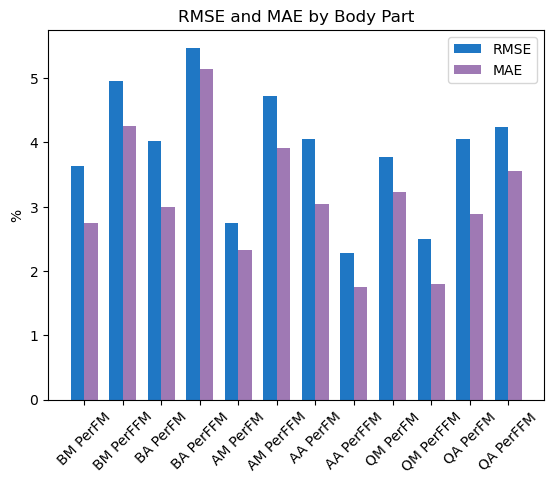

In [55]:
rmse_np = rmse.detach().cpu()
mae_np = mae.detach().cpu()

positions = torch.arange(len(body_parts))
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(positions - width/2, rmse_np.flatten(), width, label='RMSE',color ='#1f77c4')
rects2 = ax.bar(positions + width/2, mae_np.flatten(), width, label='MAE',color = '#9f79b4')

ax.set_ylabel('%')
ax.set_title('RMSE and MAE by Body Part')
ax.set_xticks(positions)
ax.set_xticklabels(body_parts)
ax.legend()

plt.xticks(rotation=45)
plt.show()